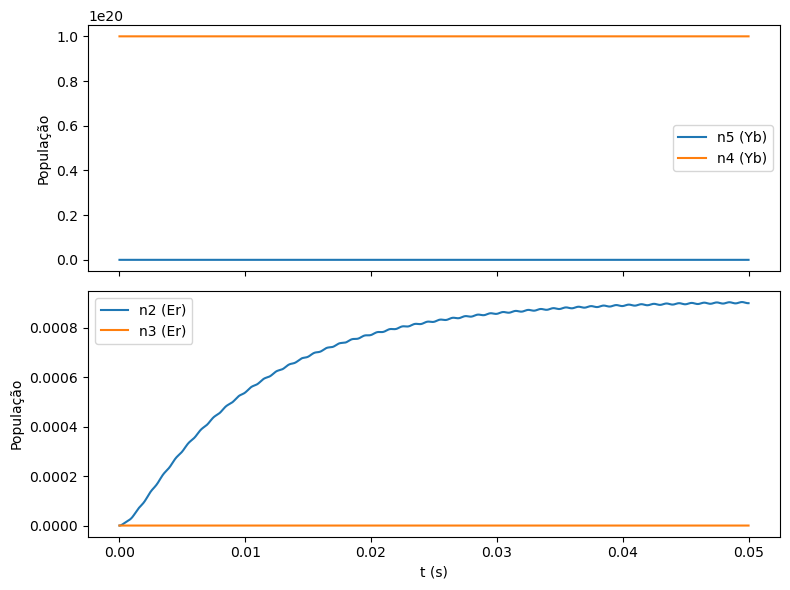

In [5]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ---- Parâmetros físicos (ajuste aos seus valores) ----
sigma = 1e-20      # cm^2, seção de choque de absorção
P     = 1.0        # W ou W/cm^2, dependendo da normalização
N_Yb  = 1e20        # concentração total de Yb (cm^-3)
N_Er  = 1e19        # concentração total de Er (cm^-3)

W51 = 1e-17   # taxas de transferência de energia (cm^3/s)
W52 = 1e-17
k54 = 1e3     # taxas de decaimento (s^-1)
k21 = 1e2
k31 = 1/(0.35e-3)

def F(t, freq=1000, mod_depth=1.0):
    """Modulação temporal do bombeio, ex: senoidal com offset"""
    return 1 + mod_depth * np.cos(2*np.pi*freq*t)
    # ou onda quadrada, pulso, etc.

# ---- Sistema de EDOs ----
def rhs(t, y):
    n5, n2, n3 = y
    n4 = N_Yb - n5
    n1 = N_Er - n2 - n3

    dn5 = sigma * P * F(t) * n4 - W51*n1*n5 - W52*n2*n5 - k54*n5
    dn2 = W51*n1*n5 - W52*n2*n5 - k21*n2
    dn3 = W52*n2*n5 - k31*n3

    return [dn5, dn2, dn3]

# ---- Condições iniciais ----
y0 = [0.0, 0.0, 0.0]   # tudo no estado fundamental inicialmente

# ---- Intervalo de integração ----
t_span = (0, 0.05)          # segundos
t_eval = np.linspace(*t_span, 5000)

# ---- Resolve ----
sol = solve_ivp(
    rhs, t_span, y0,
    method='Radau',      # bom para sistemas stiff
    t_eval=t_eval,
    rtol=1e-8, atol=1e-12
)

# ---- Plot ----
n5, n2, n3 = sol.y
n4 = N_Yb - n5
n1 = N_Er - n2 - n3

fig, axs = plt.subplots(2, 1, figsize=(8,6), sharex=True)
axs[0].plot(sol.t, n5, label='n5 (Yb)')
axs[0].plot(sol.t, n4, label='n4 (Yb)')
axs[0].legend(); axs[0].set_ylabel('População')

axs[1].plot(sol.t, n2, label='n2 (Er)')
axs[1].plot(sol.t, n3, label='n3 (Er)')
axs[1].legend(); axs[1].set_ylabel('População')
axs[1].set_xlabel('t (s)')
plt.tight_layout()
plt.show()